## Installation

```
pip install networkx python-louvain
```

In [1]:
# Dependendencies

!pip install networkx python-louvain

In [2]:
import networkx as nx

import pandas as pd
from operator import itemgetter
import matplotlib.pyplot as plt
import collections
from community import community_louvain
from networkx.algorithms.community.centrality import girvan_newman
import itertools
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
nx.__version__

'3.5'

## Introducting Networkx

NetworkX has a broad range of example networks that you can load with just a function call ([more examples here](https://networkx.github.io/documentation/stable/auto_examples/index.html)).

.. and a super friendly API that you can use to conviently build networks.

In order to get used to NetworkX API, let's just construct a simple **undirected graph**

### Creating and Visualizing a simple Undirected Graph

In [4]:
G = nx.Graph() # for a directed graph use nx.DiGraph()
G.add_node(1)
G.add_nodes_from(range(2,9))  # add multiple nodes at once

# add edges 
G.add_edge(1,2)
edges = [(2,3), (1,3), (4,1), (4,5), (5,6), (5,7), (6,7), (7,8), (6,8)]
G.add_edges_from(edges)
G.nodes()

NodeView((1, 2, 3, 4, 5, 6, 7, 8))

Did you like to get a quick overview of your dataset using `.describe()` in pandas ?
Here is the equivalent in NetworkX:

In [5]:
print(G)

Graph with 8 nodes and 10 edges


The library also has a built-in plotting engine (based on matplotlib).

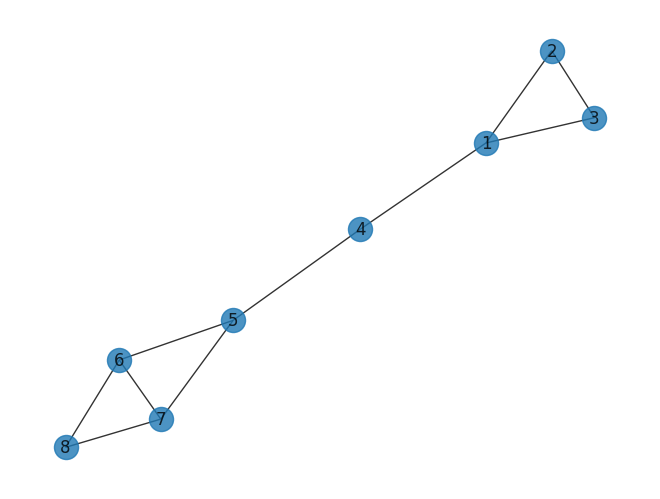

In [6]:
# plot it out
# for different layouts, please see: https://networkx.github.io/documentation/stable/reference/drawing.html#module-networkx.drawing.layout
nx.draw_spring(G, with_labels=True,  alpha = 0.8) # spring layout is a force-directed graph visualization algorithm that positions nodes in 2D space by simulating physical forces.

(moi): Helper functions are reusable functions designed to perform common, repetitive tasks to make your code cleaner and more maintainable.

In [7]:
# Helper function for plotting the degree distribution of a Graph
# The degree distribution of a graph is a histogram showing how many nodes have each possible degree (number of connections).
def plot_degree_distribution(G):
    degrees = {}
    for node in G.nodes():
        degree = G.degree(node)
        if degree not in degrees:
            degrees[degree] = 0 # initializes a dictionary entry for a degree value that hasn't been encountered yet.
        degrees[degree] += 1
    sorted_degree = sorted(degrees.items())
    # degrees.items(): Converts the dictionary into a list of tuples (degree, frequency) pairs
    # sorted(...): Sorts these tuples by their first element (the degree) in ascending order
    deg = [k for (k,v) in sorted_degree]
    cnt = [v for (k,v) in sorted_degree]
    fig, ax = plt.subplots()
    plt.bar(deg, cnt, width=0.80, color='b')
    plt.title("Degree Distribution")
    plt.ylabel("Frequency")
    plt.xlabel("Degree")
    ax.set_xticks([d+0.05 for d in deg])
    ax.set_xticklabels(deg)

In [8]:
# Helper function for printing various graph properties
def describe_graph(G):
    print(G)
    if nx.is_connected(G): # connected graph: there is a path between every pair of nodes
        print("Avg. Shortest Path Length: %.4f" %nx.average_shortest_path_length(G)) # the mean of the shortest distances (hops) between all pairs of nodes in a connected graph.
        print("Diameter: %.4f" %nx.diameter(G)) # Longest shortest path
    else:
        print("Graph is not connected")
        print("Diameter and Avg shortest path length are not defined!")
    # Sparsity measures how few edges a graph has compared to the maximum possible number of edges (all nodes connected to each other). 0 to 1
    print("Sparsity: %.4f" %nx.density(G))  # #edges/#edges-complete-graph

    # #closed-triplets (3 * #triangles)/#all-triplets
    # Triplet: three nodes where one node is connected to the other two (a "V" shape).
    # Closed triplet: a triplet where all three nodes are connected
    # (each triangle contributes 3 closed triplets).
    print("Global clustering coefficient aka Transitivity: %.4f" %nx.transitivity(G))
    # Interpretation
    # Value ∈ [0, 1]
    # 0 → no triangles (no local clustering)
    # 1 → every connected triplet forms a triangle (maximal clustering)
    # Social networks (friend-of-a-friend relationships)

In [9]:
# Helper function for visualizing the graph
def visualize_graph(G, with_labels=True, k=None, alpha=1.0, node_shape='o'):
    #nx.draw_spring(G, with_labels=with_labels, alpha = alpha)
    pos = nx.spring_layout(G, k=k) # k: represents the optimal distance between nodes in the spring layout algorithm.
    # pos est un dictionnaire qui stocke les coordonnées (x, y) de chaque nœud dans le plan 2D pour la visualisation.
    if with_labels:
        # When drawing the graph, this dictionary tells NetworkX what text to display on each node
        lab = nx.draw_networkx_labels(G, pos, labels=dict([(n, n) for n in G.nodes()])) # labels = {1: 1, 2: 2, 3: 3, 4: 4}
    ec = nx.draw_networkx_edges(G, pos, alpha=alpha) # This line draws the edges (connections) between nodes in the graph visualization.
    nc = nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_color='g', node_shape=node_shape) # nodelist=G.nodes() - Specifies which nodes to draw (all nodes in this case)
    plt.axis('off')

### Creating and Visualizing an Erdős–Rényi graph

Graph with 10 nodes and 20 edges
Avg. Shortest Path Length: 1.6000
Diameter: 3.0000
Sparsity: 0.4444
Global clustering coefficient aka Transitivity: 0.3281


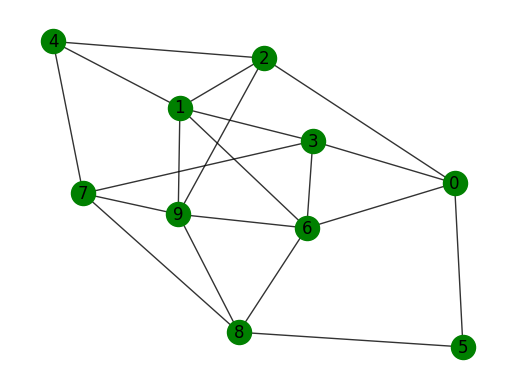

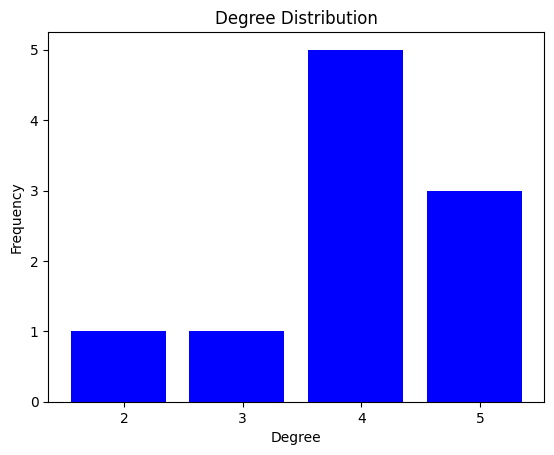

In [10]:
# An Erdős–Rényi graph is a random graph model where edges are added randomly between nodes.
n = 10  # 10 nodes
m = 20  # 20 edges

erG = nx.gnm_random_graph(n, m)

describe_graph(erG)
visualize_graph(erG, k=0.05, alpha=0.8)
plot_degree_distribution(erG)

### Creating and Visualizing the Zachary's Karate Club Network

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges
Avg. Shortest Path Length: 2.4082
Diameter: 5.0000
Sparsity: 0.1390
Global clustering coefficient aka Transitivity: 0.2557


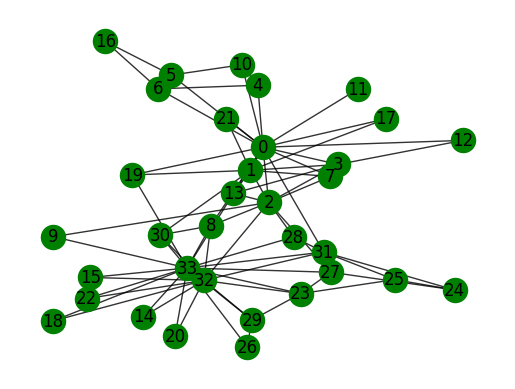

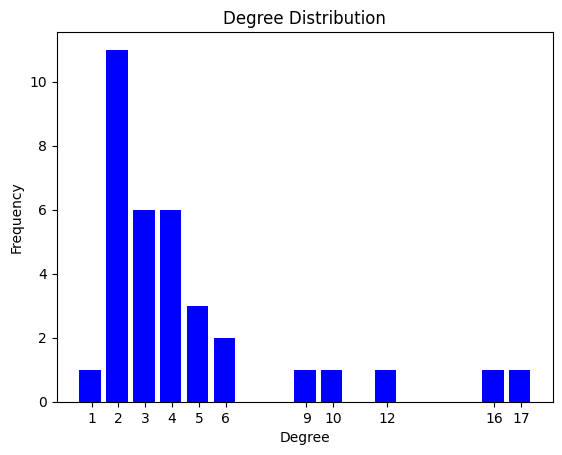

In [11]:
# Zachary's Karate Club is a famous real-world social network dataset widely used in network analysis and community detection research.
karateG = nx.karate_club_graph()
describe_graph(karateG)
visualize_graph(karateG, k=0.05, alpha=0.8)
plot_degree_distribution(karateG)

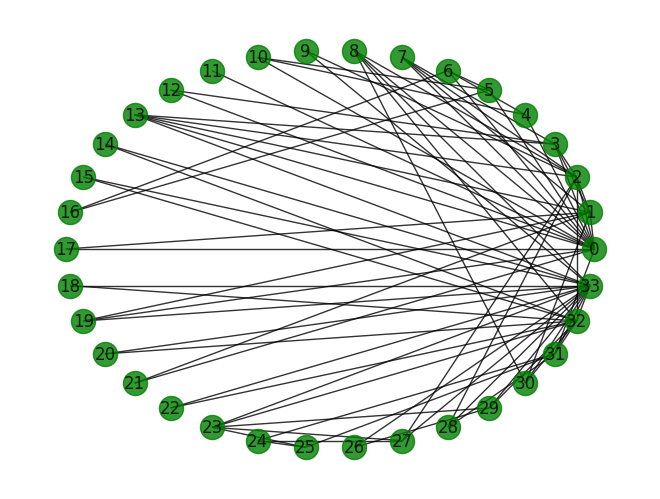

In [12]:
# Draw the graph with a circular layout instead?
nx.draw_circular(karateG, with_labels=True,  node_color='g', alpha = 0.8)

## Section 2: Quakers !

Let's now go beyond toy examples and load real data! 

England, in the mid-17th century. A novel group of Protestant Christians, called "Religious Society of Friends" dissent from the main doctrine. Their members are known as the "Quakers". This dataset is derived from the ["Oxford Dictionary of National Biography"](http://www.oxforddnb.com/) and from the ongoing work of the *"Six Degrees of Francis Bacon project"*, which is reconstructing the social networks of early modern Britain (1500-1700) to trace the personal relationships among figures like **Bacon**, **Shakespeare**, **Sir Isaac Newton** and many others.

[Credits](https://programminghistorian.org/en/lessons/exploring-and-analyzing-network-data-with-python)

### Meet the Quakers

In [13]:
data_folder = './data/quakers/'
nodes = pd.read_csv(data_folder + 'quakers_nodelist.csv')
nodes.head(10)

,Name,Historical Significance,Gender,Birthdate,Deathdate,ID
0,Joseph Wyeth,religious writer,male,1663,1731,10013191
1,Alexander Skene of Newtyle,local politician and author,male,1621,1694,10011149
2,James Logan,colonial official and scholar,male,1674,1751,10007567
3,Dorcas Erbery,Quaker preacher,female,1656,1659,10003983
4,Lilias Skene,Quaker preacher and poet,male,1626,1697,10011152
5,William Mucklow,religious writer,male,1630,1713,10008595
6,Thomas Salthouse,Quaker preacher and writer,male,1630,1691,10010643
7,William Dewsbury,Quaker activist,male,1621,1688,10003478
8,John Audland,Quaker preacher,male,1630,1664,10000411
9,Richard Claridge,Quaker minister and schoolmaster,male,1649,1723,10002469


In [14]:
nodes.Gender = nodes.Gender.astype('category') # This line converts the Gender column in the pandas DataFrame to a categorical data type.
# Before: Gender stored as strings (object dtype)
# ['Male', 'Female', 'Male', 'Female', ...] - each string stored separately

# After: Gender stored as category
# Categories: ['Male', 'Female']
# Values: [0, 1, 0, 1, ...] - only integers stored

nodes = nodes.rename({'Historical Significance': 'Role'}, axis = 1) # Renames the column 'Historical Significance' to 'Role' in the DataFrame.
print('There are ', len(nodes), 'quakers')

There are  119 quakers


In [15]:
nodes['Role'].isna().sum() # This line counts how many missing (NaN) values are in the Role column of the nodes DataFrame.

np.int64(2)

In [16]:
# some don't have a known 'historical significance' or 'role'
nodes['Role'].fillna('Unknown', inplace=True) # This line replaces all missing (NaN) values in the Role column with the string 'Unknown'.
# .fillna('Unknown') - Fills all NaN/null values with the string 'Unknown'
# inplace=True - Modifies the original DataFrame directly instead of returning a new copy

In [17]:
# check if the names are unique
len(nodes['Name'].unique()) == len(nodes) # .unique() : method returns an array of unique values from a pandas Series, removing all duplicates.

True

In [18]:
# since the names are unique, index based on names
nodes.set_index('Name', inplace=True)

# let's also add a new attribute based on the role column. Is (s)he a directly involved Quaker or not? 
nodes['Quaker'] = ['quaker' in role.lower() for role in nodes.Role]
nodes.head()

,Role,Gender,Birthdate,Deathdate,ID,Quaker
Name,,,,,,
Joseph Wyeth,religious writer,male,1663,1731,10013191,False
Alexander Skene of Newtyle,local politician and author,male,1621,1694,10011149,False
James Logan,colonial official and scholar,male,1674,1751,10007567,False
Dorcas Erbery,Quaker preacher,female,1656,1659,10003983,True
Lilias Skene,Quaker preacher and poet,male,1626,1697,10011152,True


In [19]:
# let's see which quaker knows whom, this will translate into edges in our graph
edges = pd.read_csv(data_folder + 'quakers_edgelist.csv')
edges.head()
# An edge is a connection between two nodes (vertices) in a graph. It represents a relationship or link between two entities.

,Source,Target
0,George Keith,Robert Barclay
1,George Keith,Benjamin Furly
2,George Keith,Anne Conway Viscountess Conway and Killultagh
3,George Keith,Franciscus Mercurius van Helmont
4,George Keith,William Penn


In [20]:
print('There are',len(edges), 'edges')

There are 174 edges


### The Quaker network

Now we have all the ingredients and more to translate this data into a network: nodes are the quakers and there exists an edge between two quakers if they know each other. Since being acquainted or friends is a symmetric relation, we will build an undirected graph.

Another bonus of NetworkX is the smooth integration with panda dataframes, which makes loading the network a one-liner.   
*Note: Only if you don't have isolated nodes*<br>
(moi): Isolated nodes are nodes (vertices) in a graph that have no connections to any other nodes—they have a degree of 0.

In [64]:
quakerG =nx.from_pandas_edgelist(edges, 'Source', 'Target', edge_attr=None, create_using= nx.Graph()) # edge_attr=None specifies that no edge attributes should be extracted from the DataFrame when creating the graph.
describe_graph(quakerG)

Graph with 119 nodes and 174 edges
Graph is not connected
Diameter and Avg shortest path length are not defined!
Sparsity: 0.0248
Global clustering coefficient aka Transitivity: 0.1694


In [65]:
# add node attributes by passing dictionary of type name -> attribute
# This code adds attributes (metadata) to the nodes in the graph.
nx.set_node_attributes(quakerG, nodes['Role'].to_dict(), 'Role' )
nx.set_node_attributes(quakerG, nodes['Gender'].to_dict(), 'Gender' )
nx.set_node_attributes(quakerG, nodes['Birthdate'].to_dict(), 'Birthdate' )
nx.set_node_attributes(quakerG, nodes['Deathdate'].to_dict(), 'Deathdate' )
nx.set_node_attributes(quakerG, nodes['Quaker'].to_dict(), 'Quaker' )
# nodes['Role'].to_dict() - Converts the 'Role' column from the pandas DataFrame into a dictionary where keys are Quaker names and values are their roles
# 'Role' - The name of the attribute being added
# NetworkX matches by comparing:
    # Dictionary keys (Quaker names from the DataFrame)
    # Node names in the graph (also Quaker names)

In [23]:
# You can easily get the attributes of a node
quakerG.nodes['William Penn']

{'Role': 'Quaker leader and founder of Pennsylvania',
 'Gender': 'male',
 'Birthdate': 1644,
 'Deathdate': 1718,
 'Quaker': True}

### How connected is the quaker network ?  

To get a feel of the network, we could start by visually inspecting the graph. 

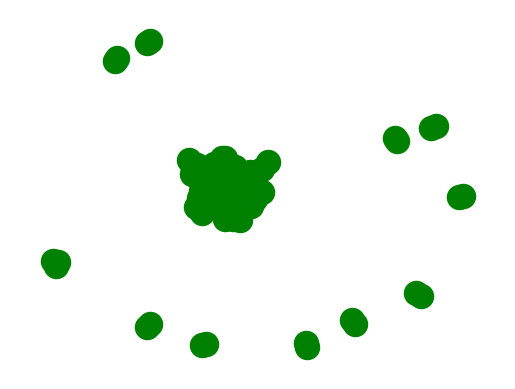

In [24]:
visualize_graph(quakerG, False, k=0.05, alpha=0.4)

Let's try to make the visualization a bit better...

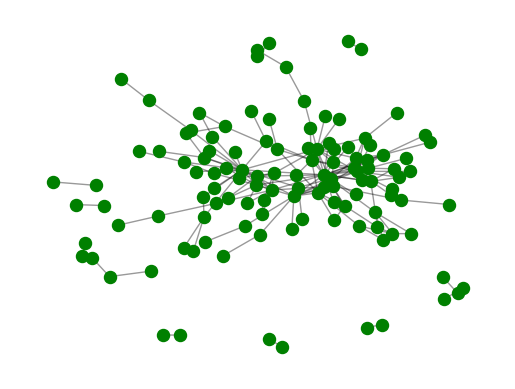

In [25]:
visualize_graph(quakerG, False, k=0.2, alpha=0.4, node_shape='.')

Still not a very pretty visualisation (.. install  [Gephy](https://gephi.org/) for some better-looking plots). However, a few things come across:

* The graph is not connected (there are a few isolated communities)
* There seem to be a few nodes with many connections (i.e. hubs)

(moi): A hub is a node in a graph that has significantly more connections (edges) than most other nodes in the network.

That's as far as we can get, let's revert to **numbers and graph properties** for more insights!

### Sparsity
"Sparsity" of a graph with $n$ nodes is defined as follows: 

$ L = \frac{|E|}{|E_{max}|}$, where $E_{max} = \frac{n * (n-1)}{2}$

In [26]:
# 174 * (2) / ( 119* 118)
print("Network sparsity: %.4f" %nx.density(quakerG))

Network sparsity: 0.0248


### Connected Components
If the graph is not connected, how many "connected components" are there ?

In [66]:
print(nx.is_connected(quakerG))
comp = list(nx.connected_components(quakerG))
# print(comp)
print('The graph contains', len(comp), 'connected components')

False
[{'Mary Prince', 'Thomas Lower', 'Henry Pickworth', 'Alexander Parker', 'Elizabeth Leavens', 'Franciscus Mercurius van Helmont', 'William Simpson', 'Sir Charles Wager', 'Richard Farnworth', 'Margaret Fell', 'Tace Sowle', 'Isaac Norris', 'James Logan', 'Jane Sowle', 'John Penington', 'Robert Barclay', 'John Camm', 'Peter Collinson', 'Samuel Bownas', 'George Keith', 'Samuel Clarridge', 'Edward Haistwell', 'Martha Simmonds', 'John Bartram', 'Thomas Holme', 'John Crook', 'John Stubbs', 'Silvanus Bevan', 'Richard Hubberthorne', 'Richard Claridge', 'Thomas Camm', 'John Audland', 'Daniel Quare', 'William Mucklow', 'Anne Camm', 'Solomon Eccles', 'George Fox', 'Charles Marshall', 'Joseph Wyeth', 'Samuel Fisher', 'Benjamin Furly', 'Leonard Fell', 'Gervase Benson', 'Thomas Lawson', 'Robert Rich', 'Francis Howgill', 'Stephen Crisp', 'William Penn', 'Anthony Sharp', 'Gilbert Latey', 'John Whitehead', 'William Edmundson', 'Mary Fisher', 'Lewis Morris', 'John Wilkinson', 'Alice Curwen', 'Isabel

In [67]:
largest_comp = max(comp, key=len)
print('Largest component nodes:', largest_comp)
percentage_lcc = len(largest_comp)/quakerG.number_of_nodes() * 100
print('The largest component has', len(largest_comp), 'nodes', 'accounting for %.2f'% percentage_lcc, '% of the nodes') 

Largest component nodes: {'Mary Prince', 'Thomas Lower', 'Henry Pickworth', 'Alexander Parker', 'Elizabeth Leavens', 'Franciscus Mercurius van Helmont', 'William Simpson', 'Sir Charles Wager', 'Richard Farnworth', 'Margaret Fell', 'Tace Sowle', 'Isaac Norris', 'James Logan', 'Jane Sowle', 'John Penington', 'Robert Barclay', 'John Camm', 'Peter Collinson', 'Samuel Bownas', 'George Keith', 'Samuel Clarridge', 'Edward Haistwell', 'Martha Simmonds', 'John Bartram', 'Thomas Holme', 'John Crook', 'John Stubbs', 'Silvanus Bevan', 'Richard Hubberthorne', 'Richard Claridge', 'Thomas Camm', 'John Audland', 'Daniel Quare', 'William Mucklow', 'Anne Camm', 'Solomon Eccles', 'George Fox', 'Charles Marshall', 'Joseph Wyeth', 'Samuel Fisher', 'Benjamin Furly', 'Leonard Fell', 'Gervase Benson', 'Thomas Lawson', 'Robert Rich', 'Francis Howgill', 'Stephen Crisp', 'William Penn', 'Anthony Sharp', 'Gilbert Latey', 'John Whitehead', 'William Edmundson', 'Mary Fisher', 'Lewis Morris', 'John Wilkinson', 'Alic

From visually inspecting the graph, we already saw that most of the nodes are in the largest component, which is often the case in a graph. That is why we usually call this component as a **giant component**.

### Diameter and Shortest Paths
Suppose I want to find the shortest path between two quakers, given that they are in the same connected component

In [29]:
fell_whitehead_path = nx.shortest_path(quakerG, source="Margaret Fell", target="George Whitehead")
print("Shortest path between Fell and Whitehead:", fell_whitehead_path)

Shortest path between Fell and Whitehead: ['Margaret Fell', 'George Fox', 'George Whitehead']


In [30]:
# take the largest component and analyse its diameter = longest shortest-path
lcc_quakerG = quakerG.subgraph(largest_comp)
print("The diameter of the largest connected component is", nx.diameter(lcc_quakerG))
print("The avg shortest path length of the largest connected component is", nx.average_shortest_path_length(lcc_quakerG))

The diameter of the largest connected component is 8
The avg shortest path length of the largest connected component is 3.3789473684210525


### A more social look at the network!

**Triadic Closure:**   
    A *friend* of my *friend* is my *friend*   
    OR   
    *quaker_1* knows *quaker_2* and *quaker_2* knows *quaker_3*, how likely is that *quaker_1* and *quaker_3* know each other?

Employ a **global** measure called **transitivity** (aka global clustering coefficient), or the ratio of all existing triangles (closed triples) over all possible triangles (open and closed triplets).

In [31]:
print('%.4f' %nx.transitivity(quakerG))

0.1694


Employ a **local** measure called **clustering coefficient**, which quantifies for a node how close its neighbours are to being a clique (complete graph). Measured as the ratio of, the number of edges to the number of all possible edges, among the neighbors of a node.

In [32]:
# Similar measure but for individual nodes called clustering coefficient
print(nx.clustering(quakerG, ['Alexander Parker', 'John Crook']))
# Among all my neighbors, how many of them are connected to each other?

{'Alexander Parker': 0.06666666666666667, 'John Crook': 0.8333333333333334}


In [69]:
# Lets check by looking at the subgraphs induced by Alex and John # todo here
subgraph_Alex = quakerG.subgraph(['Alexander Parker']+list(quakerG.neighbors('Alexander Parker'))) # quakerG.neighbors() returns an iterator (object that produces a sequence of values, one at a time). Wrapping it with list(...) materializes the neighbors so you can concatenate them with ['Alexander Parker'], producing the full node list to pass to subgraph() (focal node + its neighbors).
subgraph_John = quakerG.subgraph(['John Crook']+list(quakerG.neighbors('John Crook')))

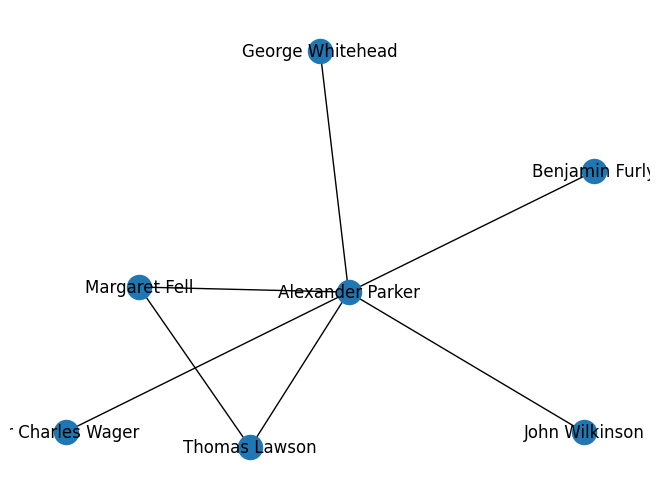

In [34]:
nx.draw_spring(subgraph_Alex, with_labels=True)

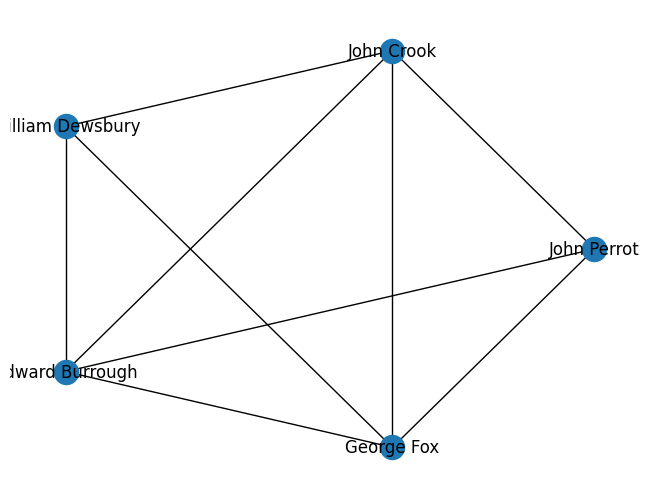

In [35]:
nx.draw_circular(subgraph_John, with_labels=True)

### Which quakers are the most important ?

As always, the answer is ... it depends. There are many ways to detect important nodes in a graph, for example based on:

* **Degree** (generalized by **Katz**)
* **Betweeness centrality**
* More ...

#### Degree: the more people you know, the more important you are!

In [36]:
degrees = dict(quakerG.degree(quakerG.nodes())) # It queries the degree for every node in quakerG (quakerG.degree(quakerG.nodes()) returns (node, degree) pairs) and turns that into a Python dict mapping each node name to its degree.
sorted_degree = sorted(degrees.items(), key=itemgetter(1), reverse=True) # degrees.items() gives (node, degree) pairs; sorted(..., key=itemgetter(1), reverse=True) orders those pairs by their second element (the degree) in descending order; the result is the list sorted_degree with nodes sorted from highest to lowest degree.

# And the top 5 most popular quakers are.. 
for quaker, degree in sorted_degree[:5]:
    print(quaker, 'who is', quakerG.nodes[quaker]['Role'], 'knows', degree, 'people')

George Fox who is  a founder of the Religious Society of Friends (Quakers) knows 22 people
William Penn who is Quaker leader and founder of Pennsylvania knows 18 people
James Nayler who is Quaker preacher and writer knows 16 people
George Whitehead who is Quaker leader and writer knows 13 people
Margaret Fell who is Quaker leader knows 13 people


Let's also analyze the *degree distribution*. 
We can see that most of the people know less than 5 quakers and there are some *leaders that are comparatively very popular*. 

Counter({1: 51, 2: 33, 3: 9, 4: 6, 5: 5, 6: 4, 13: 2, 8: 2, 7: 2, 22: 1, 18: 1, 16: 1, 10: 1, 9: 1})
   index  0
0     22  1
1     18  1
2     16  1
3     13  2
4     10  1


Text(0.5, 1.0, 'Degree distribution for the Quaker network')

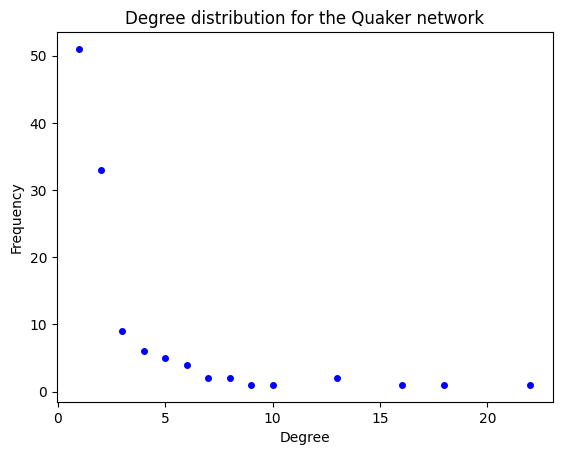

In [72]:
degree_seq = [d[1] for d in sorted_degree]
degreeCount = collections.Counter(degree_seq) # It builds a frequency table of node degrees: given degree_seq (a list of degree values), collections.Counter returns a dict‑like object mapping each degree to how many times it appears.
print(degreeCount)
degreeCount = pd.DataFrame.from_dict( degreeCount, orient='index').reset_index() # orient='index' tells pd.DataFrame.from_dict() to use the dictionary keys as the DataFrame index (rows) and the dictionary values as a single column. In this case, degrees become row labels and their frequencies become the column values.
print(degreeCount.head())
# .reset_index() converts the index back into a regular column. After .from_dict() with orient='index', the degrees are the index. .reset_index() moves them into a named column ('index'), making the DataFrame easier to work with for plotting—you can access degree values via degreeCount['index'].
fig = plt.figure()
ax = plt.gca() # returns a reference to the current axes (the active plot area). You can then use ax to customize that plot—for example, to set tick positions with ax.set_xticks() or modify other axis properties.
ax.plot(degreeCount['index'], degreeCount[0], 'o', c='blue', markersize= 4) # degreeCount[0] accesses the second column of the DataFrame (column index 0, which is the first unnamed column after .reset_index()).
# After .reset_index(), the DataFrame has two columns:
#     'index' — the degree values
#     0 — the frequencies (counts)
plt.ylabel('Frequency')
plt.xlabel('Degree')
plt.title('Degree distribution for the Quaker network')

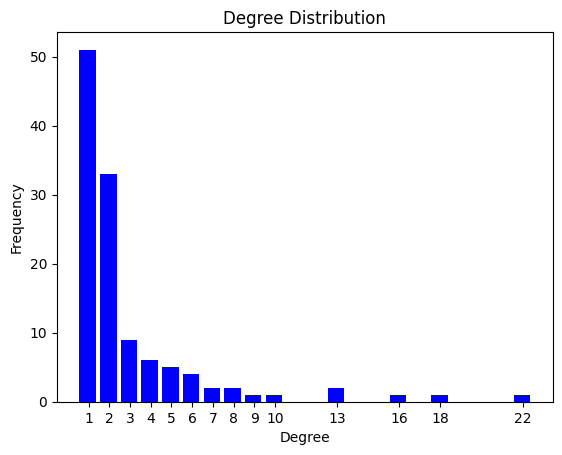

In [38]:
# As a bar plot
plot_degree_distribution(quakerG)

#### What about the Katz Centrality (the generalization over degree centrality)?

## (moi) What is Katz Centrality?

**Katz centrality** is a generalization of degree centrality that measures node importance by considering both direct connections and indirect connections through the network.

### Key differences from degree centrality:

- **Degree centrality**: Only counts direct neighbors (nodes you're connected to)
- **Katz centrality**: Counts all paths from a node to other nodes, with distant nodes weighted less heavily

### Formula intuition:

A node's Katz centrality score is the sum of contributions from all other nodes, where each contribution decays exponentially based on the path length. Closer nodes contribute more than distant ones.

### When to use it:

- When you want to capture influence through both direct and indirect connections
- Social networks where influence can propagate through intermediaries
- More nuanced than simple degree, but computationally heavier for very large graphs

In the Quakers network, Katz centrality identifies the most important Quakers by considering not just who they directly know, but also their connections to well-connected people in the network.

In [39]:
degrees = dict(quakerG.degree(quakerG.nodes()))

katz = nx.katz_centrality(quakerG)
nx.set_node_attributes(quakerG, katz, 'katz')
sorted_katz = sorted(katz.items(), key=itemgetter(1), reverse=True)

# And the top 5 most popular quakers are.. 
for quaker, katzc in sorted_katz[:5]:
    print(quaker, 'who is', quakerG.nodes[quaker]['Role'], 'has katz-centrality: %.3f' %katzc)

George Fox who is  a founder of the Religious Society of Friends (Quakers) has katz-centrality: 0.342
James Nayler who is Quaker preacher and writer has katz-centrality: 0.261
William Penn who is Quaker leader and founder of Pennsylvania has katz-centrality: 0.249
George Whitehead who is Quaker leader and writer has katz-centrality: 0.216
Margaret Fell who is Quaker leader has katz-centrality: 0.215


Note: this is an undirected graph. If you were to have a **directed** one, use separate metrics for **indegree** and **outdegree**.

#### Betweeness centrality: the more shortest paths pass through a node, the more important it is!

In [40]:
# Compute betweenness centrality
betweenness = nx.betweenness_centrality(quakerG)
# Assign the computed centrality values as a node-attribute in your network
nx.set_node_attributes(quakerG, betweenness, 'betweenness')
sorted_betweenness = sorted(betweenness.items(), key=itemgetter(1), reverse=True)

for quaker, bw in sorted_betweenness[:5]:
    print(quaker, 'who is', quakerG.nodes[quaker]['Role'], 'has betweeness: %.3f' %bw)

William Penn who is Quaker leader and founder of Pennsylvania has betweeness: 0.240
George Fox who is  a founder of the Religious Society of Friends (Quakers) has betweeness: 0.237
George Whitehead who is Quaker leader and writer has betweeness: 0.126
Margaret Fell who is Quaker leader has betweeness: 0.121
James Nayler who is Quaker preacher and writer has betweeness: 0.104


Let's analyze the betweeness centrality values for all the nodes in the network. As in the case with degree, there are a *few nodes with very high betweeness centrality*, while most of them have a low value.

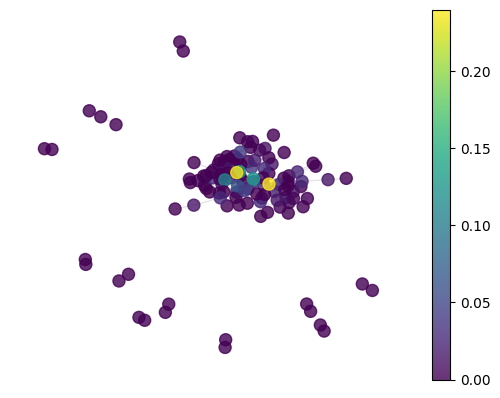

In [ ]:
# similar pattern
list_nodes =list(quakerG.nodes())
list_nodes.reverse()   # for showing the nodes with high betweeness centrality 
# It flips the list_nodes order in-place so the subsequent draw call plots nodes in the opposite order—useful to control layering/visibility (e.g., making the nodes intended to stand out get drawn last and stay visible on top).

pos = nx.spring_layout(quakerG) # pos is the dictionary of 2D coordinates produced by nx.spring_layout(quakerG). It maps each node to an (x, y) position for plotting the graph.
ec = nx.draw_networkx_edges(quakerG, pos, alpha=0.1)
nc = nx.draw_networkx_nodes(quakerG, pos, nodelist=list_nodes, node_color=[quakerG.nodes[n]["betweenness"] for n in list_nodes], 
                            alpha=0.8, node_shape = '.') # nodelist explicitly sets which nodes to draw and in what order.
plt.colorbar(nc)
plt.axis('off')
plt.show()

At this point you might be tempted to think the measures are very similar, but let's revisit the original graph (G)

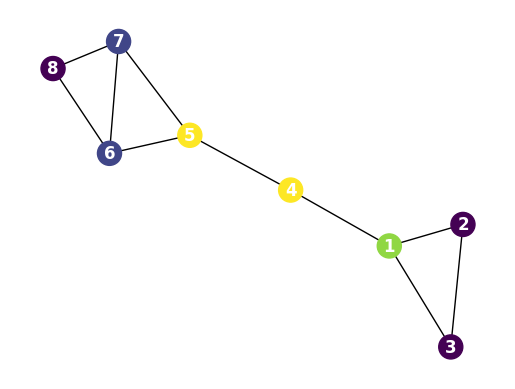

In [42]:
nx.set_node_attributes(G, nx.betweenness_centrality(G), 'betweenness')
pos = nx.spring_layout(G)
ec = nx.draw_networkx(G, pos, nodelist=G.nodes(),
                         node_color=[G.nodes[n]["betweenness"] for n in G.nodes()], 
                         node_shape = '.', node_size=1200, font_color="white", font_weight="bold")
plt.colorbar(nc)
plt.axis('off')
plt.show()

The node with the **lowest degree** is the one with the **highest betweeness centrality**. 

This concept also translates to edges. In particular, edge betweeness is the number of shortest paths that pass through an edge. This brings us to ...

### The quaker communities

Community detection is a common class of methods applied to graphs. 
Two important algorithms:
* **Girvan Newman**
* **Louvain**

#### Girvan Newman
**Idea:** Edges possessing high betweeness centrality separate communities. Let's apply this on our toy sample graph (G) to get a better understanding of the idea.

The algorithm starts with the entire graph and then it iteratively removes the edge with the highest betweeness.

In [ ]:
comp = girvan_newman(G) # the generator returned by girvan_newman(G) that yields successive community partitions as edges are removed.
it = 0 # a simple counter to label which iteration/partition you’re looking at when looping over comp.
for communities in itertools.islice(comp, 4): # It iterates over the first four community partitions produced by the comp generator. itertools.islice(comp, 4) takes only the first 4 yielded partitions from comp (the Girvan–Newman generator), and the for loop processes each of those partitions in turn.
    it +=1
    print('Iteration', it)
    print(tuple(sorted(c) for c in communities)) # sorted(c) takes the iterable c (one community set) and returns its members in ascending order as a list, just to print the community nodes in a consistent, readable order.

Iteration 1
([1, 2, 3, 4], [5, 6, 7, 8])
Iteration 2
([1, 2, 3], [4], [5, 6, 7, 8])
Iteration 3
([1, 2, 3], [4], [5], [6, 7, 8])
Iteration 4
([1], [2, 3], [4], [5], [6, 7, 8])


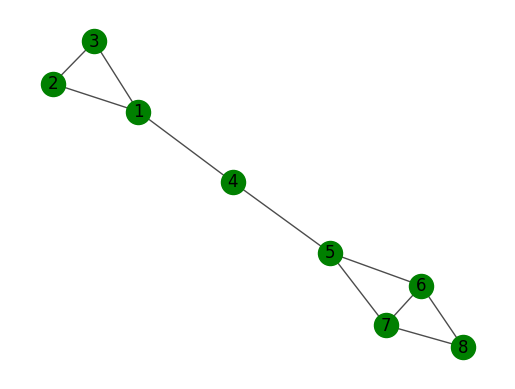

In [44]:
visualize_graph(G,alpha=0.7)

#### The [Louvain method](https://en.wikipedia.org/wiki/Louvain_Modularity)

Another clustering algorithm and has become a standard algorithm in the data scientist toolbox.   
**Idea:** It proceeds the other way around: initially every node is considered as a community. The communities are traversed, and for each community it is tested whether by joining it to a neighboring community, we can obtain a better clustering. 

## (moi) How the Louvain Method Works

The **Louvain method** is a greedy algorithm for community detection that optimizes **modularity** (the quality of a network partition).

### Algorithm Steps:

1. **Initialization**: Each node starts as its own community
2. **Phase 1 - Local optimization**: 
   - Traverse (iterates through each community one by on) each community (or node)
   - Test if moving it to a neighboring community increases modularity
   - If yes, move it; if no, keep it in its current community
   - Repeat until no further improvements
3. **Phase 2 - Aggregation**: 
   - Compress the network by treating each community as a single node
   - Create new edges between communities based on their internal connections
4. **Iteration**: Repeat phases 1-2 until the algorithm converges (no more modularity gains)

### Key Advantages:

- **Bottom-up approach**: Merges communities (opposite of Girvan-Newman which removes edges top-down)
- **Fast**: Efficient even for large networks
- **Modularity optimization**: Directly maximizes the quality metric
- **Practical**: Widely used in data science and network analysis

### Result:
Returns a **partition** dictionary mapping each node to its detected community ID.

In [45]:
partition = community_louvain.best_partition(quakerG)
# add it as an attribute to the nodes
for n in quakerG.nodes:
    quakerG.nodes[n]["louvain"] = partition[n]

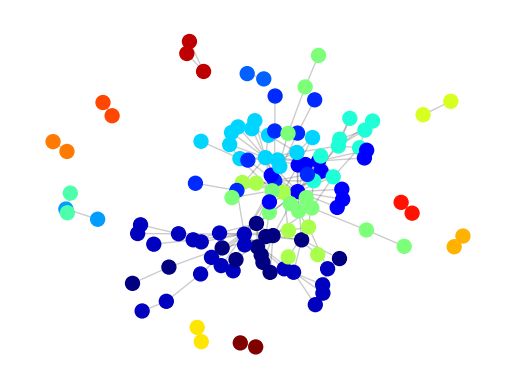

In [ ]:
# plot it out
pos = nx.spring_layout(quakerG,k=0.2)
ec = nx.draw_networkx_edges(quakerG, pos, alpha=0.2)
nc = nx.draw_networkx_nodes(quakerG, pos, nodelist=quakerG.nodes(), node_color=[quakerG.nodes[n]["louvain"] for n in quakerG.nodes], 
                            node_size=100, cmap=plt.cm.jet) # cmap=plt.cm.jet specifies a colormap for mapping numeric values to colors in the visualization.
plt.axis('off')
plt.show()

Let's get a closer look at a few clusters and show their member's role and period in which they lived

In [ ]:
cluster_James = partition['James Nayler'] # This line retrieves the community ID that James Nayler belongs to from the Louvain partition.
# Take all the nodes that belong to James' cluster
members_c = [q for q in quakerG.nodes if partition[q] == cluster_James]
# get info about these quakers
for quaker in members_c:
    print(quaker, 'who is', quakerG.nodes[quaker]['Role'], 'and died in ',quakerG.nodes[quaker]['Deathdate'])

Dorcas Erbery who is Quaker preacher and died in  1659
James Nayler who is Quaker preacher and writer and died in  1660
Francis Howgill who is Quaker activist and died in  1669
Martha Simmonds who is Quaker and author and died in  1665
Richard Farnworth who is Quaker preacher and writer and died in  1666
William Crouch who is Quaker leader and writer and died in  1711
Hannah Stranger who is Quaker missionary and died in  1671
Gervase Benson who is Quaker leader and died in  1679
Robert Rich who is Quaker adherent and sectary and died in  1679
Anthony Pearson who is Quaker administrator and died in  1666
William Tomlinson who is religious writer and died in  1696
Richard Hubberthorne who is Quaker activist and died in  1662
Thomas Aldam who is Quaker preacher and writer and died in  1660


In [48]:
cluster_Lydia = partition['Lydia Lancaster']
# Take all the nodes that belong to Lydia's cluster
members_c = [q for q in quakerG.nodes if partition[q] == cluster_Lydia]
# get info about these quakers
for quaker in members_c:
    print(quaker, 'who is', quakerG.nodes[quaker]['Role'], 'and died in ',quakerG.nodes[quaker]['Deathdate'])

Lydia Lancaster who is Quaker minister and died in  1761
Grace Chamber who is Quaker minister and died in  1762


### Homophily in quakers

(moi) Homophily: the tendency for individuals to associate and bond with others who are similar to them.<br>
homophily ranges from -1 to 1.<br>
It's measured using the assortativity coefficient, similar to correlation:
- Close to +1: Strong positive homophily = similar nodes tend to connect
- Close to 0: No homophily = connections are random with respect to that attribute
- Close to -1: Strong negative homophily (disassortative) = dissimilar nodes tend to connect

How likely is it that two quakers who have the same attribute are linked?

Try to measure the similarity of connections in the graph with respect to a given attribute.   
*Intuition: Like correlation, but translated to graphs.*

In [49]:
# for categorical attributes
nx.attribute_assortativity_coefficient(quakerG, 'Gender')

0.1882377889305155

In [76]:
nodes.groupby('Gender').size()

Gender
female    22
male      97
dtype: int64

There is no notion of *gender homophily* in this network, which makes sense due to the following:
* Couples
* Gender imbalance

However, there exists **age homophily**: quakers that died in the same period are more likely to be linked

In [51]:
# for numerical attributes, values must be integers
nx.numeric_assortativity_coefficient(quakerG, 'Deathdate')

0.5841284189309789

### Few Exercises
1. Visually determine the diameter of the small graph we built at the beginning (G) and then check you got it right.
2. Experiment with the Girvan Newman algorithm on the Quaker (quakerG) network.
3. Compute role homophily in the Quaker network.   
*Hint: You can either do it based on the given roles you have or develop a more coarse (grossière) categorisation of roles and repeat your analysis after.*

**Quiz A: Given the following adjacency matrix of a graph:**

<img src="imgs/quizA.png">

1. A is a directed graph with average in-degree 4/3
2. A is an undirected graph with average degree 4/3
3. A is a directed graph with average in-degree 1
4. A is an undirected graph with average degree 1

## (moi) Understanding Adjacency Matrices, In-Degree, and Quiz A

### Adjacency Matrix

An **adjacency matrix** is a square matrix representation of a graph where:
- **Rows** represent source nodes
- **Columns** represent target nodes
- **Entry A[i,j]** = 1 if there's an edge from node i to node j, 0 otherwise

Example for a directed graph with 3 nodes:
```
    1  2  3
1 [ 0  1  0 ]  ← Node 1 has edges going OUT to node 2
2 [ 1  0  1 ]  ← Node 2 has edges going OUT to nodes 1 and 3
3 [ 0  1  0 ]  ← Node 3 has edges going OUT to node 2
```

**Key property**: For **directed graphs**, the matrix is NOT necessarily symmetric. For **undirected graphs**, the matrix IS symmetric (A[i,j] = A[j,i]).

### In-Degree vs Out-Degree

In a **directed graph**:
- **In-degree** of node i = number of edges **pointing INTO** node i = sum of column i
- **Out-degree** of node i = number of edges **pointing OUT FROM** node i = sum of row i

In an **undirected graph**, we just say "degree" (edges are bidirectional).

### Why Quiz A Answer is 1

Looking at the adjacency matrix in Quiz A, to determine the answer:

1. **Check if symmetric**: If A[i,j] ≠ A[j,i] for some i,j → **directed graph**. Otherwise → **undirected**.
2. **Count edges**: Sum all 1s in the matrix
3. **Calculate average in-degree**: Total edges ÷ Number of nodes

For answer 1 to be correct ("directed graph with average in-degree 4/3"):
- The matrix must be **non-symmetric** (directed)
- Total number of 1s = 4 (meaning 4 edges)
- Number of nodes = 3 (since 3×3 matrix)
- Average in-degree = 4 ÷ 3 = 4/3

This matches answer **1** because:
✓ The adjacency matrix is not symmetric → directed
✓ Sum of all entries = 4 → 4 edges total
✓ Average in-degree = 4 edges ÷ 3 nodes = **4/3**

In [52]:
#1

**Quiz B: In a horror scenario, your lost luggage is landing at an airport and being loaded to another random flight and transferred to another airport. This has been going on for months. Given a very large number of iterations, which of the following metrics gives you the probability that your luggage ends up in Geneva airport?**

1. Closeness centrality
2. Page rank
3. Betweenness centrality
4. Katz similarity

## (moi) Understanding PageRank and Quiz B

### What is PageRank?

**PageRank** is an algorithm that measures the probability that a random walker lands on a particular node after many steps in a network.

**Key idea**: Imagine a person randomly clicking links on web pages (or in this case, luggage randomly being transferred between airports). After many, many steps, there's a steady-state probability of being at each page/airport. PageRank computes this probability.

**Formula intuition**: A node's PageRank depends on:
- How many nodes link to it (in-degree)
- The PageRank of those incoming nodes (popular pages pointing to you make you popular)
- A damping factor (the random walker might "jump" to any node with some probability)

### Why Quiz B Answer is 2 (PageRank)

The scenario describes a **random walk process**:
- Luggage lands randomly → transported to random airport → transported again randomly → repeat many times
- After a "very large number of iterations" → **steady-state probability distribution**

This is exactly what PageRank calculates!

### Why NOT the others?

1. **Closeness centrality** (option 1): Measures average shortest path distance to all other nodes from one node. NOT about random walks or probability.

2. **Betweenness centrality** (option 3): Measures how many shortest paths pass through a node. NOT about random walk steady-state.

3. **Katz similarity** (option 4): Measures node similarity based on path counts with exponential decay. NOT about steady-state probabilities.

### Answer: 2 ✓

**PageRank** directly gives you the probability that a randomly walking process (luggage transfers) will be at each location (Geneva airport) in the long run.

This is why Google uses PageRank—it simulates how likely a random surfer lands on each webpage!

In [53]:
#2

### Take it further 
Course at Stanford taught by Jure Leskovec: http://web.stanford.edu/class/cs224w/

(Better) alternative to NetworkX, see igraph: http://igraph.org/python/

For larger graph analysis:

* Apache GraphX: https://spark.apache.org/graphx/
* Apache Giraph: http://giraph.apache.org
* Webgraph: http://webgraph.di.unimi.it/
* SNAP: http://snap.stanford.edu/snap/
* Graph tool: https://graph-tool.skewed.de
* Network kit: https://networkit.iti.kit.edu/api/structures.html
* Pajek: http://mrvar.fdv.uni-lj.si/pajek/
* Network Workbench: http://nwb.cns.iu.edu

## (moi) Conclusion

This notebook provided a comprehensive introduction to **network analysis using NetworkX**, with a focus on real-world social network data (the Quakers dataset).

### Key Topics Covered:

1. **Graph Fundamentals**: Created and visualized simple graphs, understood nodes, edges, and various graph types (directed, undirected, random)

2. **Network Properties**: Measured connectivity (sparsity, connected components), distance metrics (diameter, shortest paths), and clustering (transitivity, clustering coefficients)

3. **Centrality Measures**: Explored multiple ways to identify important nodes:
   - **Degree centrality**: counts direct connections
   - **Katz centrality**: generalizes degree by considering indirect paths
   - **Betweenness centrality**: identifies nodes that bridge communities
   - **Closeness centrality**: measures proximity to all other nodes

4. **Community Detection**: Learned two fundamental algorithms:
   - **Girvan-Newman**: top-down edge removal based on betweenness
   - **Louvain**: bottom-up modularity optimization (more efficient)

5. **Network Characteristics**: Analyzed homophily—the tendency for similar nodes to connect (age homophily existed in Quakers, gender homophily did not)

6. **Graph Algorithms**: Understood key concepts like PageRank, adjacency matrices, directed/undirected graphs, in-degree/out-degree

### Takeaway:

NetworkX provides an intuitive API for transforming data into graphs and extracting meaningful insights about network structure, node importance, and community organization—essential skills for analyzing social networks, biological networks, and complex systems.